In [1]:
import numpy as np
from tensorflow import keras
from keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
print(x_train[:1])

x_train = x_train/255
print(x_train[:1])

x_test = x_test/255

[[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
     0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
     0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
     0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
     0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
     0   0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126
   136 175  26 166 255 247 127   0   0   0   0]
  [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253
   253 225 172 253 242 195  64   0   0   0   0]
  [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253
   251  93  82  82  56  39   0   0   0   0   0]
  [  0   0   0   0   0   0   0  18 219 253 253 2

In [5]:
print(y_train[:5])

y_train = keras.utils.to_categorical(y_train, num_classes=10)
print(y_train[:5])


[5 0 4 1 9]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [6]:
from keras.models import Model
from keras import Sequential
from keras.layers import Conv1D, BatchNormalization, Dense, Flatten, Dropout
from keras import Input

In [7]:
i_layer = Input(shape=(28,28))

x = Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')(i_layer)
x = BatchNormalization(momentum=0.9)(x)
x = Dropout(0.2)(x)

x = Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')(x)
x = BatchNormalization(momentum=0.9)(x)
x = Dropout(0.2)(x)

x = Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')(x)
x = BatchNormalization(momentum=0.9)(x)
x = Dropout(0.2)(x)

x = Flatten()(x)
x = Dense(units=128, activation='relu')(x)
x = Dropout(0.2)(x)

o_layer = Dense(units=10, activation='softmax')(x)

model = Model(i_layer, o_layer)

In [8]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 28, 32)         │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 28, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 28, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,418 (489.91 KB)

 Trainable params: 125,226 (489.16 KB)

 Non-trainable params: 192 (768.00 B)

In [9]:
model.fit(x_train, y_train, batch_size=1000, epochs=10, validation_split=0.2, verbose=2)

Epoch 1/10
48/48 - 11s - 225ms/step - accuracy: 0.7061 - loss: 0.9187 - val_accuracy: 0.9269 - val_loss: 0.2368
Epoch 2/10
48/48 - 10s - 214ms/step - accuracy: 0.9080 - loss: 0.2897 - val_accuracy: 0.9522 - val_loss: 0.1474
Epoch 3/10
48/48 - 7s - 140ms/step - accuracy: 0.9363 - loss: 0.2073 - val_accuracy: 0.9652 - val_loss: 0.1114
Epoch 4/10
48/48 - 10s - 201ms/step - accuracy: 0.9484 - loss: 0.1665 - val_accuracy: 0.9720 - val_loss: 0.0949
Epoch 5/10
48/48 - 10s - 206ms/step - accuracy: 0.9545 - loss: 0.1451 - val_accuracy: 0.9743 - val_loss: 0.0843
Epoch 6/10
48/48 - 7s - 148ms/step - accuracy: 0.9618 - loss: 0.1228 - val_accuracy: 0.9768 - val_loss: 0.0779
Epoch 7/10
48/48 - 6s - 123ms/step - accuracy: 0.9655 - loss: 0.1100 - val_accuracy: 0.9783 - val_loss: 0.0696
Epoch 8/10
48/48 - 7s - 147ms/step - accuracy: 0.9687 - loss: 0.1013 - val_accuracy: 0.9794 - val_loss: 0.0676
Epoch 9/10
48/48 - 6s - 123ms/step - accuracy: 0.9706 - loss: 0.0935 - val_accuracy: 0.9802 - val_loss: 0.06

In [10]:
prediction = model.predict(x_test)
print(prediction[:5])

prediction = np.argmax(prediction, axis=-1)
print(prediction[:5])
print(y_test[:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[1.4875953e-09 4.8232323e-08 2.0639000e-07 6.5936996e-07 4.5336912e-10
  1.4297417e-09 3.8520537e-11 9.9999827e-01 1.4981556e-10 6.6121754e-07]
 [1.3008097e-09 6.7493515e-05 9.9992794e-01 1.4953328e-06 5.2595867e-10
  4.7339623e-07 2.5582433e-06 6.5601027e-12 2.0155145e-08 1.7419184e-12]
 [1.8327108e-07 9.9989229e-01 1.3457657e-05 1.9925368e-07 7.3393778e-05
  1.2904924e-06 1.9245122e-06 1.6292666e-05 7.6320504e-07 1.5240029e-07]
 [9.9977922e-01 7.3245531e-08 7.5794846e-06 2.8284112e-06 2.0145960e-06
  3.9247448e-06 1.1153683e-04 2.1108840e-06 6.8545960e-06 8.4011306e-05]
 [2.3823856e-09 1.8078255e-08 2.0709631e-08 9.0270289e-09 9.9997336e-01
  4.7874590e-08 4.7673279e-07 8.3021705e-06 2.5950541e-08 1.7792217e-05]]
[7 2 1 0 4]
[7 2 1 0 4]


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [12]:
ac_score = accuracy_score(y_test, prediction)
print(ac_score)

conf_matrix = confusion_matrix(y_test, prediction)
print(conf_matrix)

0.9825
[[ 973    0    0    0    2    1    2    1    1    0]
 [   0 1129    3    0    0    1    1    0    1    0]
 [   3    2 1013    7    0    0    0    5    2    0]
 [   0    0    2  991    0    7    0    3    1    6]
 [   2    0    3    0  962    0    0    2    0   13]
 [   2    0    0    3    2  875    4    2    1    3]
 [   7    3    0    1    1    5  939    0    2    0]
 [   1    7    4    1    1    0    0 1010    0    4]
 [   6    0    3    4    0    0    1    2  955    3]
 [   2    5    0    5    9    2    0    4    4  978]]


In [13]:
import seaborn as sns

Text(50.722222222222214, 0.5, 'actual')

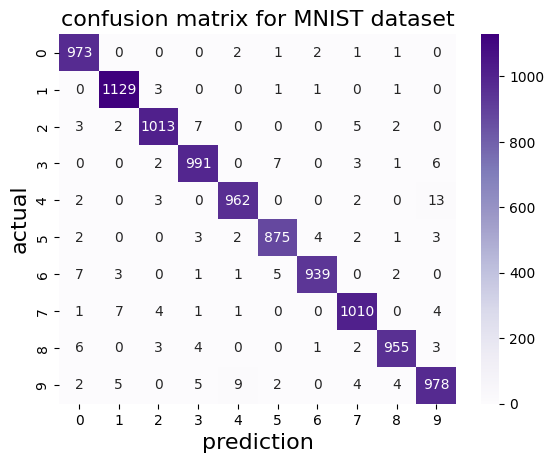

In [14]:
ax = sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples')
ax.set_title('confusion matrix for MNIST dataset', fontsize=16)
ax.set_xlabel('prediction', fontsize=16)
ax.set_ylabel('actual', fontsize=16)